<a target="_blank" href="https://colab.research.google.com/github/NX-AI/tirex-2/blob/main/examples/getting_started.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open Notebook In Google Colab"/>
</a>

# TiRex-2 - Getting Started

This notebook gives a quick introduction on how to work with **TiRex-2**, an improved version of TiRex with **additional support for past and future covariates**. If you are already familiar with TiRex, the most notable API change for users is that a list of `TimeseriesType`s has to be provided when calling the `forecast` method, rather than a time series directly. This offers the advantage of being able to clearly specify what time series should be forecast, which should serve as past and which as future covariates:

```py
@dataclass
class TimeseriesType:
    target: torch.Tensor
    past_covariates: torch.Tensor | None
    future_covariates: torch.Tensor | None
```

## Table of Contents

- [Table of Contents](#table-of-contents)
- [Installation](#installation)
    - [Via Pip](#via-pip)
    - [Direct installation](#direct-installation)
    - [Via Pixi](#via-pixi)
- [Setup](#setup)
- [Load model](#load-model)
- [Data](#data)
    - [Holidays](#holidays)
    - [Non-Stationary](#non-stationary)
- [Forecasting](#forecasting)
    - [Single target variates](#single-target-variates)
    - [Multiple target variates](#multiple-target-variates)
    - [Output types](#output-types)
    - [Batchsize and generator](#batch-size-and-generator)

## Installation

There are several ways to run this notebook:

### CPU only versions
If you would like to use the CPU-only version of TiRex, please first install
the CPU versions of torch and torchvision via the following command:
```bash
pip install "torch<2.10" torchvision --index-url https://download.pytorch.org/whl/cpu
```
While the installation below also succeeds without running the above, the installation process will be faster and less dependencies are installed.

### Via `pip`
```bash
# create virtual environment
python -m venv venv

# activate environment
source venv/bin/activate

# install TiRex-2 and optional dependencies
# - from PiPy
pip install -q "tirex-2[examples,gluonts]"
# - from source
# pip install -q -e "tirex-2[examples,gluonts] @ git+https://github.com/NX-AI/tirex-2.git"

# launch notebook
jupyter lab 
```

### Direct installation
In case you are already running jupyter, you can directly install TiRex-2 and all dependencies via one of the following commands.

In [1]:
# From PiPy
%pip install -q "tirex-2[examples,gluonts]"

# From the repository root
# %pip install -q -e ".[examples,gluonts]"

# From Github
# %pip install -q "tirex-2[examples,gluonts] @ git+https://github.com/NX-AI/tirex-2.git"


### Via `pixi`
[Pixi](https://pixi.prefix.dev/latest/#pixi) is a package management tool that ensures that all dependencies and requirements are met. Internally, it is also used for development purposes. To setup the environment, run the following lines from inside the root directory.

```bash
# install pixi package management tool
curl -fsSL https://pixi.sh/install.sh | sh

# launch this notebook
pixi run notebook
```

In [3]:
# install dependencies
import numpy as np
import torch

# tirex-2 functionality
from tirex2 import ForecastModel, TimeseriesType, load_model
from tirex2.demo import Demo, plot_demo_forecast
from tirex2.plotting import plot_multivariate

W0702 13:50:57.836000 777290 site-packages/torch/utils/cpp_extension.py:117] No CUDA runtime is found, using CUDA_HOME='/home/cg/NXAI/GitHub/tirex-2/.pixi/envs/example-cu128'
/home/cg/NXAI/GitHub/tirex-2/.pixi/envs/example-cu128/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load model

In [4]:
# define model and device
ckpt = "NX-AI/TiRex-2"
device = "cpu"
# device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading checkpoint '{ckpt}' for device '{device}'")

# load model
model: ForecastModel = load_model(ckpt, device=device)

# report its properties
quantile_levels = [round(float(q), 3) for q in model.quantiles.detach().cpu().numpy()]
print("- native quantiles:", quantile_levels)
print("- maximum supported prediction length:", model.future_len)

Loading checkpoint 'NX-AI/TiRex-2' for device 'cpu'
- native quantiles: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
- maximum supported prediction length: 320


## Data
We provide two sample datasets that allow showcasing the merits of using multivariate data in forecasting. As already described previously, **TiRex-2** requires a list of `TimeseriesType` objects as basis for forecasting. Each object has:

- `target`: tensor with shape `(n_target_variates, context_length)`
- `past_covariates`: optional tensor with shape `(n_past_covariates, context_length)`
- `future_covariates`: optional tensor with shape `(n_future_covariates, context_length + prediction_length)`

In the following, we build these objects from our demo data.

### Holidays

In [5]:
demo_holidays = Demo.create_holidays_demo()
demo_holidays.describe()

----------------------------------------------------------------------
Demo Dataset
----------------------------------------------------------------------
Title:       TiRex-2 with a future-known covariate (holiday calendar)
Description: Daily demand with known holidays. As they are irregular, they are unpredictable from history alone.


In [6]:
# univariate target history (1, context_length)
target = torch.from_numpy(demo_holidays.target_context).unsqueeze(0)

# future-known covariates must cover both the observed context and the forecast horizon: (n_covariates, context_length + horizon)
future_covariates = torch.from_numpy(
    np.stack([np.concatenate([c.context, c.future]) for c in demo_holidays.covariates]).astype(np.float32)
)

print("Shape of target signal:", tuple(target.shape))
print("Shape of future covariates:", tuple(future_covariates.shape))

Shape of target signal: (1, 540)
Shape of future covariates: (1, 582)


In [7]:
# univariate / target-only forecast
univariate_holidays = TimeseriesType(
    target=target,
    past_covariates=None,
    future_covariates=None,
)

# multivariate forecast conditioning: the target plus future-known covariates.
multivariate_holidays = TimeseriesType(
    target=target,
    past_covariates=None,
    future_covariates=future_covariates,
)

### Non-stationary

In [8]:
demo_nonstationary = Demo.create_nonstationary_demo()
demo_nonstationary.describe()

----------------------------------------------------------------------
Demo Dataset
----------------------------------------------------------------------
Title:       TiRex-2 on a non-stationary series (continuous driver + promotion flag)
Description: A continuous covariate sets the wandering level, while a binary flag adds spikes. The model model needs both covariates for solid forecasts.


In [9]:
# univariate target history (1, context_length)
target = torch.from_numpy(demo_nonstationary.target_context).unsqueeze(0)

# future-known covariates must cover both the observed context and the forecast horizon: (n_covariates, context_length + horizon)
future_covariates = torch.from_numpy(
    np.stack([np.concatenate([c.context, c.future]) for c in demo_nonstationary.covariates]).astype(np.float32)
)

print("Shape of target signal:", tuple(target.shape))
print("Shape of future covariates:", tuple(future_covariates.shape))

Shape of target signal: (1, 540)
Shape of future covariates: (2, 582)


In [10]:
# univariate / target-only forecast
univariate_nonstationary = TimeseriesType(
    target=target,
    past_covariates=None,
    future_covariates=None,
)

# multivariate forecast conditioning: the target plus future-known covariates.
multivariate_nonstationary = TimeseriesType(
    target=target,
    past_covariates=None,
    future_covariates=future_covariates,
)

## Forecasting
While TiRex-2 bases its forecasts on `TimeseriesType` objects, it returns forecasts only for the target variates as different types, depending on `output_type` (see below).  
**Note:** Covariates are simply conditioning information, and as such, are not forecast.

### Holidays

In [11]:
# perform forecast
forecasts = model.forecast(
    timeseries=[univariate_holidays, multivariate_holidays],
    prediction_length=demo_holidays.horizon,
    output_type="numpy",
    batch_size=2,
)

# extract results, each item has shape (n_target_variates, n_quantiles, prediction_length)
univariate_forecast = forecasts[0]
multivariate_forecast = forecasts[1]

print("Shape of univariate forecast:", univariate_forecast.shape)
print("Shape of multivariate-conditioned forecast:", multivariate_forecast.shape)

/home/cg/NXAI/GitHub/tirex-2/.pixi/envs/example-cu128/lib/python3.13/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Shape of univariate forecast: (1, 9, 42)
Shape of multivariate-conditioned forecast: (1, 9, 42)


We now compare the forecasts for **univariate and multivariate inputs** to show the **metrits of** the additional **covariate information**. For simplicity, we wrap the comparison in another plotting function.

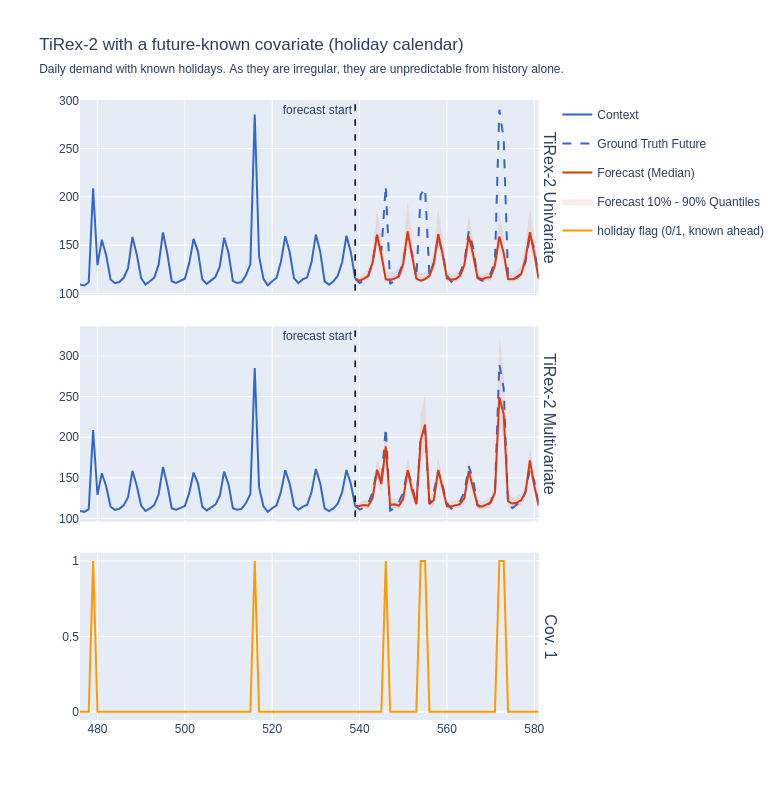

In [12]:
plot_demo_forecast(demo_holidays, univariate_forecast, multivariate_forecast)

### Non-stationary

In [13]:
# perform forecast
forecasts = model.forecast(
    timeseries=[univariate_nonstationary, multivariate_nonstationary],
    prediction_length=demo_nonstationary.horizon,
    output_type="numpy",
    batch_size=2,
)

# extract results, each item has shape (n_target_variates, n_quantiles, prediction_length)
univariate_forecast = forecasts[0]
multivariate_forecast = forecasts[1]

print("Shape of univariate forecast:", univariate_forecast.shape)
print("Shape of multivariate-conditioned forecast:", multivariate_forecast.shape)

Shape of univariate forecast: (1, 9, 42)
Shape of multivariate-conditioned forecast: (1, 9, 42)


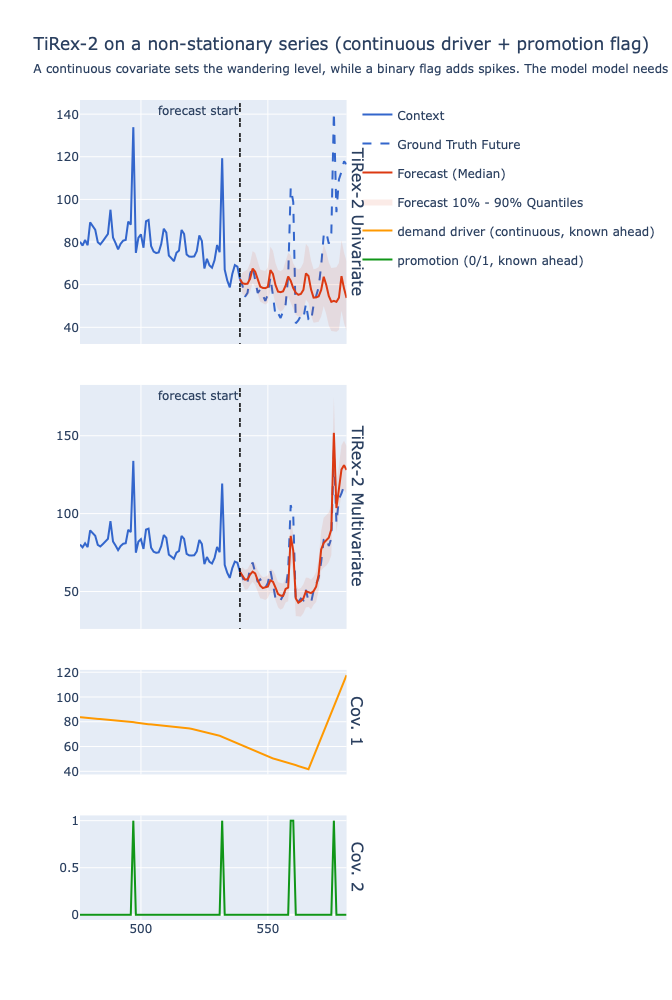

In [14]:
plot_demo_forecast(demo_nonstationary, univariate_forecast, multivariate_forecast)

## Visualization
We provide the utility function `plot_multivariate` that easily allows plotting the input and forecasts for individual targets. This function also 
allows you to decide between a static plot (`engine=matplotlib`), and an interactive plot (`engine=plotly`).

In [15]:
# defining parameters as dict to make it easier to see what changes between calls; same as providing it directly as keyword arguments to plot_multivariate()
plot_params = dict(
    # input forecast is based on
    input=multivariate_nonstationary,
    # forecast from the TiRex model
    forecast=multivariate_forecast,
    # target to display (defaults to first target)
    target_index=0,
    # ground truth for the target (optional)
    ground_truth=demo_nonstationary.target_future,
    # covariate labels for the past and future covariates
    past_cov_labels=[c.label for c in demo_nonstationary.covariates if c.future is None],
    future_cov_labels=[c.label for c in demo_nonstationary.covariates if c.future is not None],
    # which quantiles to display (defaults to 0.1 and 0.9)
    quantiles=(0.1, 0.9),
    # to limit the amount of context shown in the plot
    max_context_to_show=100,
    # title and subtitle for the plot
    title="Multivariate Forecast Plot",
    subtitle="Displaying forecast with context covariates",
)

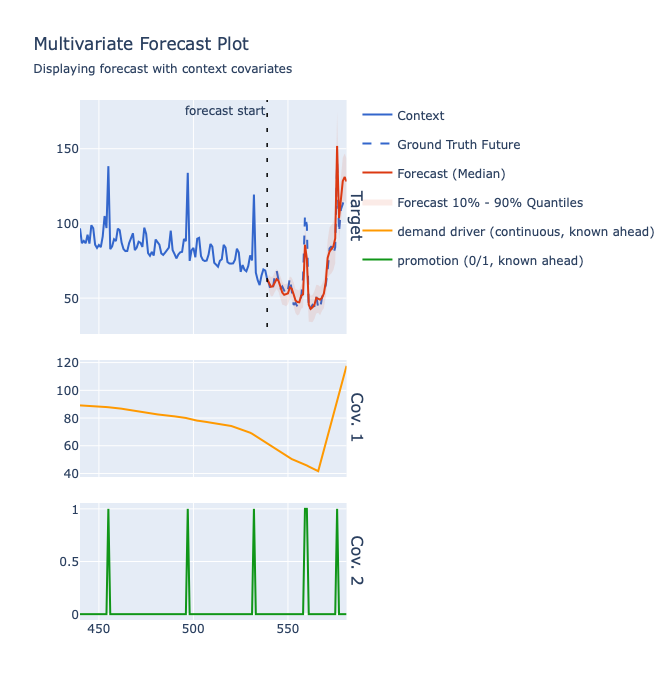

In [16]:
plot_multivariate(
    **plot_params,
    engine="plotly",
)

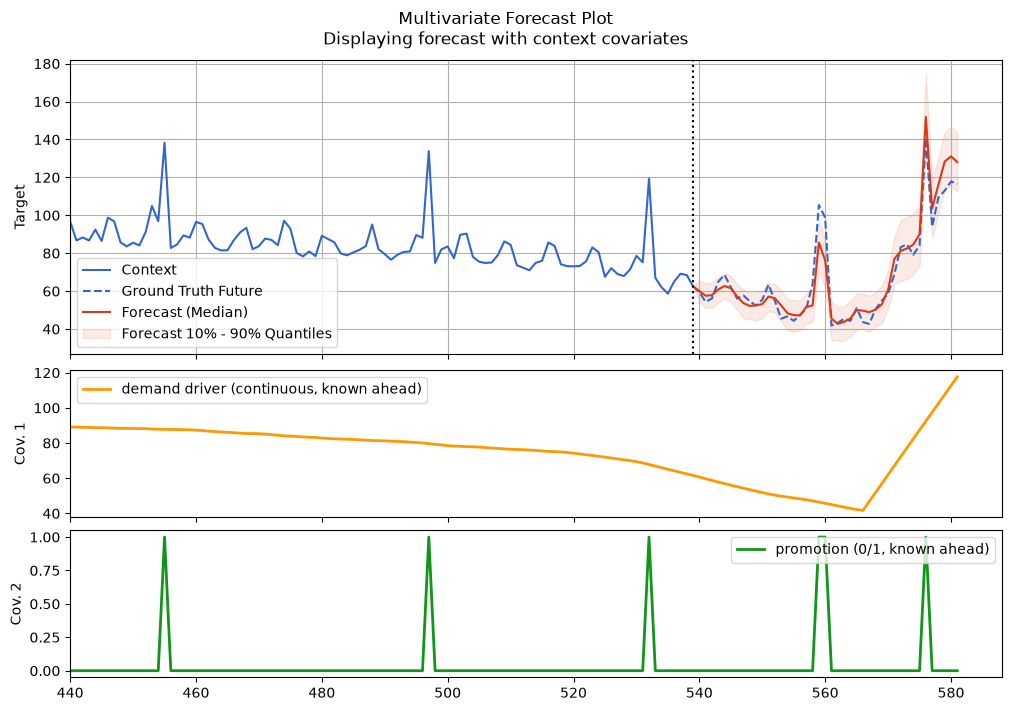

In [17]:
# catch return value to prevent showing plot twice
_ = plot_multivariate(
    **plot_params,
    engine="matplotlib",
)

## Additional features
### Multiple target variates

For a true multi-target forecast, stack several target histories in `target`. The output then has one forecast per target variate.

In [18]:
prediction_length = demo_holidays.horizon

multi_target = torch.stack(
    [
        torch.from_numpy(demo_holidays.target_context),
        torch.from_numpy(demo_nonstationary.target_context),
    ]
)

multi_target_ts = TimeseriesType(
    target=multi_target,
    past_covariates=None,
    future_covariates=None,
)

multi_target_forecast = model.forecast(
    [multi_target_ts],
    prediction_length=prediction_length,
    output_type="torch",
    batch_size=1,
)[0]

print("multi-target input shape:", tuple(multi_target.shape))
print("multi-target forecast shape:", tuple(multi_target_forecast.shape))
print("shape convention: (n_target_variates, n_quantiles, prediction_length)")

multi-target input shape: (2, 540)
multi-target forecast shape: (2, 9, 42)
shape convention: (n_target_variates, n_quantiles, prediction_length)


### Output types

`forecast` returns a list with one forecast per input `TimeseriesType`. Each forecast has shape `(n_target_variates, n_quantiles, prediction_length)`. Supported direct output types are `"torch"`, `"numpy"`, and `"gluonts"` (with optional dependencies installed). FEV output is available through `model.forecast_fev(..., output_type="fev")` for FEV evaluation windows.

In [19]:
torch_forecast = model.forecast(
    [univariate_holidays],
    prediction_length=prediction_length,
    output_type="torch",
    batch_size=1,
)[0]
print("Torch output:", type(torch_forecast), tuple(torch_forecast.shape))

numpy_forecast = model.forecast(
    [univariate_holidays],
    prediction_length=prediction_length,
    output_type="numpy",
    batch_size=1,
)[0]
print("NumPy output:", type(numpy_forecast), numpy_forecast.shape)

try:
    gluonts_forecasts = model.forecast(
        [univariate_holidays],
        prediction_length=prediction_length,
        output_type="gluonts",
        batch_size=1,
    )
    print("GluonTS output:", type(gluonts_forecasts), type(gluonts_forecasts[0]))
except Exception as exc:
    print(
        "GluonTS output unavailable (install the optional gluonts dependencies to enable it):",
        exc,
    )

Torch output: <class 'torch.Tensor'> (1, 9, 42)
NumPy output: <class 'numpy.ndarray'> (1, 9, 42)


/home/cg/NXAI/GitHub/tirex-2/.pixi/envs/example-cu128/lib/python3.13/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


GluonTS output: <class 'list'> <class 'gluonts.model.forecast.QuantileForecast'>


### Batch size and generator

Control throughput/memory with `batch_size`. If a CUDA out-of-memory error happens for a batch, TiRex-2 clears the CUDA cache, halves the current batch size, and retries the same window. This repeats until the batch fits. If a single series still does not fit, the OOM is re-raised.

Use `yield_per_batch=True` to return a **generator** that yields forecasts batch by batch instead of all at onces.

In [20]:
timeseries_batch = [
    univariate_holidays,
    multivariate_holidays,
    univariate_holidays,
    multivariate_holidays,
]

print("Manual batching with batch_size=2:")
for batch_id, batch_forecasts in enumerate(
    model.forecast(
        timeseries_batch,
        prediction_length=prediction_length,
        output_type="torch",
        batch_size=2,
        yield_per_batch=True,
    )
):
    print(f"  batch {batch_id}: {len(batch_forecasts)} forecasts, shapes = {[tuple(f.shape) for f in batch_forecasts]}")

Manual batching with batch_size=2:
  batch 0: 2 forecasts, shapes = [(1, 9, 42), (1, 9, 42)]
  batch 1: 2 forecasts, shapes = [(1, 9, 42), (1, 9, 42)]
